This week we will be learning about aggregations and using them to do a deeper investigation into the effects of different types of joins. 

We will also do a few problems exploring matrix inverses. 

### Tutorials
- https://www.datacamp.com/community/tutorials/pandas-multi-index
- https://www.datacamp.com/community/tutorials/pandas-split-apply-combine-groupby

## Grouping Data

The expressiveness of Python and pandas allows complex group operations using any function that accepts a pandas object or NumPy array. This can include:

- Splitting a pandas object into pieces using one or more keys
- Calculating group summary statistics
- Applying within-group transformations or other manipulations
- Computing pivot tables and cross-tabulations
- Performing quantile analysis and other statistical group analyses

### GroupBy Operations

Group operations involve the `split-apply-combine` mechanism.

1. Data are split into groups based on one or more keys
2. A function is applied to each group
3. Results of the function application are combined into a new object

Grouping keys can take many forms, and the keys do not have to be all of the same type.

pandas `groupby` method returns a GroupBy object that can be re-used.

DataFrame columns can be used as the group keys.

Numeric aggregations will exclude `nuisance` (non-numeric) columns from the result

By default `groupby` groups on axis=0, but can group on any of the other axes.

### Iterating over groups

The GroupBy object supports iteration, generating a sequence of 2-tuples containing the group name along with the chunk of data.

Indexing a GroupBy object created from a DataFrame with a column name or array of column names has the effect of column subsetting for aggregation. This means that:
```
df.groupby('key1')['data1']
```
is essentially the same as:
```
df['data1'].groupby(df['key1'])
```

### Reindexing

The output of GroupBys are often multi-indexed. This is typically not the form you want for your analysis. This means that you will want to reset your index or remove multi indexes on your columns. See below for examples of that. 

In [6]:
import pandas as pd
import numpy as np

speeds = pd.DataFrame(
    [
        ("bird", "Falconiformes", 389.0, 0),
        ("bird", "Psittaciformes", 24.0, 0),
        ("mammal", "Carnivora", 80.2, 0),
        ("mammal", "Primates", np.nan, 0),
        ("mammal", "Carnivora", 58, 0),
    ],
    index=["falcon", "parrot", "lion", "monkey", "leopard"],
    columns=("class", "order", "max_speed", 'min_speed'),
)

not_reindexed = speeds.groupby(["class", "order"]).agg(['sum', 'mean'])
not_reindexed

max_speed        min_speed     
                            sum   mean       sum mean
class  order                                         
bird   Falconiformes      389.0  389.0         0  0.0
       Psittaciformes      24.0   24.0         0  0.0
mammal Carnivora          138.2   69.1         0  0.0
       Primates             0.0    NaN         0  0.0

In [7]:
not_reindexed.columns = ["_".join(i) for i in not_reindexed.columns]
not_reindexed

max_speed_sum  max_speed_mean  min_speed_sum  \
class  order                                                          
bird   Falconiformes           389.0           389.0              0   
       Psittaciformes           24.0            24.0              0   
mammal Carnivora               138.2            69.1              0   
       Primates                  0.0             NaN              0   

                       min_speed_mean  
class  order                           
bird   Falconiformes              0.0  
       Psittaciformes             0.0  
mammal Carnivora                  0.0  
       Primates                   0.0

In [8]:
not_reindexed.reset_index()

,class,order,max_speed_sum,max_speed_mean,min_speed_sum,min_speed_mean
0,bird,Falconiformes,389.0,389.0,0,0.0
1,bird,Psittaciformes,24.0,24.0,0,0.0
2,mammal,Carnivora,138.2,69.1,0,0.0
3,mammal,Primates,0.0,NaN,0,0.0


### All Data Descriptions


* `customers` - A table of customers. The unique id for the customer is `customer_id` meaning only one id per customer. 
* `orders` - A table of orders. The unique id for the order is `order_id` there is a foreign key (`customer_id`) that tells you which customer placed the order.
* `web_visits`: Describes visitors to the website, with `visitor_id` be a unique id per visitor to the website. If the visitor is a logged in customer then the `customer_id` has a value otherwise it is null. 
* `ad_clicks`: Describes clicks on ad on an external website, the `external_user_id` is an unique id per user from the external website. If the user is a known in customer then the `customer_id` has a value otherwise it is null. 

In [9]:
import generate_week_10_data

customers, orders, web_visits, ad_clicks = generate_week_10_data.create_data()

### Problem 1 (10 pts)

1. What is the order amount per `customer_name`, only include customers who have orders
2. What is the order amount per `customer_name`, include customers even if they have no orders

#### Grading: 
5 points per question. 2 points for the correct join and 3 point for the aggragations. 

In [11]:
p1_inner = customers.merge(orders, on="customer_id", how="inner")

# Inner join only keeps customers who actually have orders

order_amount_per_customer_inner = (
    p1_inner
    .groupby("customer_name", as_index=False)["order_amount"]
    .sum()
    .rename(columns={"order_amount": "total_order_amount"})
)

order_amount_per_customer_inner

,customer_name,total_order_amount
0,amputator,392.529244
1,chyloid,1648.153348
2,dermatoma,997.920841
3,digitogenin,709.626087
4,lamnectomy,1583.329018
5,rapscallionly,997.713906
6,receivership,1215.266089
7,shita,866.183315
8,tasselet,547.586156


In [13]:
# Left join keeps all customers  even those without orders
p1_left = customers.merge(orders, on="customer_id", how="left")

order_amount_per_customer_left = (
    p1_left
    .groupby("customer_name", as_index=False)["order_amount"]
    .sum(min_count=1)  # this keeps NaN if a customer has no rows with values
    .fillna({"order_amount": 0})
    .rename(columns={"order_amount": "total_order_amount"})
)

order_amount_per_customer_left

,customer_name,total_order_amount
0,amputator,392.529244
1,chyloid,1648.153348
2,dermatoma,997.920841
3,digitogenin,709.626087
4,lamnectomy,1583.329018
5,rapscallionly,997.713906
6,receivership,1215.266089
7,septal,0.000000
8,shita,866.183315
9,tasselet,547.586156


### Problem 2 (5 pts)
If you look at the raw results of the join you can visually see that there are duplicates for the columns that started in the `customer` table. This wasn't a concern above because we we doing an aggregation on a column in the `orders` table. Let's think through problems that require a join but are looking to do an aggregation with a column from the `customers` table. 

1. What is the average `customer_age` for customers who have placed orders. For this problem print the accurate average `customer_age` with duplicates remove and also print the inaccure average `customer_age` without duplicates removed. 
2. What is the average `customer_age` for customers who have placed orders versus those who haven't. 

#### Grading: 
5 points per question. 2 points for the correct join and 3 point for the aggragations. 

In [15]:
# Join customers to orders
customers_orders = customers.merge(orders, on="customer_id", how="inner")

# Inaccurate: duplicate customer rows remain if a customer placed multiple orders
inaccurate_avg_age = customers_orders["customer_age"].mean()

# Accurate: remove duplicate customers first
accurate_avg_age = (
    customers_orders[["customer_id", "customer_age"]]
    .drop_duplicates()
    ["customer_age"]
    .mean()
)

print("Accurate average customer_age (duplicates removed):", accurate_avg_age)
print("Inaccurate average customer_age (duplicates kept):", inaccurate_avg_age)

Accurate average customer_age (duplicates removed): 13.37020780941142
Inaccurate average customer_age (duplicates kept): 11.238533777962948


In [18]:
# Find which customers have at least one order
customers_has_orders = customers.merge(
    orders[["customer_id"]].drop_duplicates().assign(has_order=True),
    on="customer_id",
    how="left"
)

customers_has_orders["has_order"] = customers_has_orders["has_order"].fillna(False)

avg_age_by_order_status = (
    customers_has_orders
    .groupby("has_order", as_index=False)["customer_age"]
    .mean()
)

avg_age_by_order_status

/var/folders/hw/2bcz1h_j0mx716j479vwdbk40000gq/T/ipykernel_74898/4188025893.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  customers_has_orders["has_order"] = customers_has_orders["has_order"].fillna(False)


,has_order,customer_age
0,False,27.767543
1,True,13.370208


### Problem 3 

Per customer what is the total number of web visits and ads clicked on? 

For this problem I want you to start with the `customers_visits_clicks_raw` table below and again do an accurate count that only counts a web visit once and an inaccurate count that counts duplications. Here is what the results should look like: 

<img src="images/number_visits_clicks.png" width="800"/>


#### Grading: 
5 points for joining correctly. 5 points for the correct aggragtions.  


In [20]:
# Start with this dataset 
customers_visits_clicks_raw = customers.merge(web_visits, on="customer_id", how="left").merge(ad_clicks, on="customer_id", how="left")
customers_visits_clicks_raw.head()


,customer_id,customer_age,customer_name,interaction_id,date_x,time_on_page,visitor_id,click_id,date_y,ad_id,external_user_id
0,1,27.767543,septal,1.0,2024-05-01,77.383030,124.0,5.0,2024-05-04,7792.0,98793.0
1,1,27.767543,septal,15.0,2024-05-04,26.221566,124.0,5.0,2024-05-04,7792.0,98793.0
2,2,0.747070,lamnectomy,9.0,2024-05-02,76.324059,248.0,15.0,2024-05-08,5030.0,197586.0
3,3,22.811336,digitogenin,NaN,NaT,NaN,NaN,14.0,2024-05-07,6333.0,296379.0
4,4,26.956940,shita,17.0,2024-05-04,2.539978,496.0,6.0,2024-05-05,8893.0,395172.0


In [22]:
# This overcounts because each web visit can be repeated across ad click matches and vice versa
inaccurate_counts = (
    customers_visits_clicks_raw
    .groupby("customer_name", as_index=False)
    .agg(
        web_visits_count=("visitor_id", "count"),
        ad_clicks_count=("external_user_id", "count")
    )
)

inaccurate_counts

,customer_name,web_visits_count,ad_clicks_count
0,amputator,0,3
1,chyloid,0,2
2,dermatoma,0,1
3,digitogenin,0,1
4,lamnectomy,1,1
5,rapscallionly,3,3
6,receivership,2,0
7,septal,2,2
8,shita,1,1
9,tasselet,1,0


In [23]:
# Count distinct web visit identities per customer
visits_per_customer = (
    web_visits.dropna(subset=["customer_id"])
    .groupby("customer_id", as_index=False)
    .agg(web_visits_count=("visitor_id", "nunique"))
)

# Count distinct ad click identities per customer
clicks_per_customer = (
    ad_clicks.dropna(subset=["customer_id"])
    .groupby("customer_id", as_index=False)
    .agg(ad_clicks_count=("external_user_id", "nunique"))
)

accurate_counts = (
    customers[["customer_id", "customer_name"]]
    .merge(visits_per_customer, on="customer_id", how="left")
    .merge(clicks_per_customer, on="customer_id", how="left")
    .fillna({"web_visits_count": 0, "ad_clicks_count": 0})
)

accurate_counts[["web_visits_count", "ad_clicks_count"]] = (
    accurate_counts[["web_visits_count", "ad_clicks_count"]].astype(int)
)

accurate_counts

,customer_id,customer_name,web_visits_count,ad_clicks_count
0,1,septal,1,1
1,2,lamnectomy,1,1
2,3,digitogenin,0,1
3,4,shita,1,1
4,5,dermatoma,0,1
5,6,tasselet,1,0
6,7,chyloid,0,1
7,8,amputator,0,1
8,9,receivership,1,0
9,10,rapscallionly,1,1


### Problem 4 (5 pts)

We will now work through a problem with outer joins.

Create a dataframe with the daily number of: 
* web visits
* unique web visitors
* unique customers visiting website
* ads clicks
* unique users clicking
* unique customers clicking

You should include the full date range 2024-05-01 to 2024-05-09 even though not all dates are included in either dataframe. 

You will create this data frame two ways:
1. Join `web_visits` to `ad_clicks` first and then perform the calculations
2. Create aggregate dataframes for `web_visits` to `ad_clicks` first and then join those aggregate dataframes together

#### Grading: 
5 points per method. 2 points for the correct join and 3 point for the aggragations. 

In [24]:
web_visits["date"] = pd.to_datetime(web_visits["date"])
ad_clicks["date"] = pd.to_datetime(ad_clicks["date"])

full_dates = pd.DataFrame({
    "date": pd.date_range("2024-05-01", "2024-05-09", freq="D")
})

In [ ]:
# join raw tbles first then calculate
p4_method1_raw = web_visits.merge(
    ad_clicks,
    on="date",
    how="outer",
    suffixes=("_visit", "_click")
)

p4_method1 = (
    p4_method1_raw
    .groupby("date", as_index=False)
    .agg(
        web_visits=("visitor_id", "count"),
        unique_web_visitors=("visitor_id", "nunique"),
        unique_customers_visiting=("customer_id_visit", lambda x: x.dropna().nunique()),
        ad_clicks=("external_user_id", "count"),
        unique_users_clicking=("external_user_id", "nunique"),
        unique_customers_clicking=("customer_id_click", lambda x: x.dropna().nunique())
    )
)

p4_method1 = (
    full_dates
    .merge(p4_method1, on="date", how="left")
    .fillna(0)
)

count_cols = [
    "web_visits", "unique_web_visitors", "unique_customers_visiting",
    "ad_clicks", "unique_users_clicking", "unique_customers_clicking"
]
p4_method1[count_cols] = p4_method1[count_cols].astype(int)

p4_method1

,date,web_visits,unique_web_visitors,unique_customers_visiting,ad_clicks,unique_users_clicking,unique_customers_clicking
0,2024-05-01,4,4,1,0,0,0
1,2024-05-02,5,5,2,0,0,0
2,2024-05-03,10,5,3,10,1,1
3,2024-05-04,15,5,2,15,3,3
4,2024-05-05,3,1,0,3,3,2
5,2024-05-06,0,0,0,3,3,2
6,2024-05-07,0,0,0,3,3,2
7,2024-05-08,0,0,0,3,3,2
8,2024-05-09,0,0,0,3,3,0


In [ ]:
# aggregate first, then join aggregated tables
web_daily = (
    web_visits
    .groupby("date", as_index=False)
    .agg(
        web_visits=("visitor_id", "count"),
        unique_web_visitors=("visitor_id", "nunique"),
        unique_customers_visiting=("customer_id", lambda x: x.dropna().nunique())
    )
)

click_daily = (
    ad_clicks
    .groupby("date", as_index=False)
    .agg(
        ad_clicks=("external_user_id", "count"),
        unique_users_clicking=("external_user_id", "nunique"),
        unique_customers_clicking=("customer_id", lambda x: x.dropna().nunique())
    )
)

p4_method2 = (
    full_dates
    .merge(web_daily, on="date", how="left")
    .merge(click_daily, on="date", how="left")
    .fillna(0)
)

p4_method2[count_cols] = p4_method2[count_cols].astype(int)

p4_method2


,date,web_visits,unique_web_visitors,unique_customers_visiting,ad_clicks,unique_users_clicking,unique_customers_clicking
0,2024-05-01,4,4,1,0,0,0
1,2024-05-02,5,5,2,0,0,0
2,2024-05-03,5,5,3,2,1,1
3,2024-05-04,5,5,2,3,3,3
4,2024-05-05,1,1,0,3,3,2
5,2024-05-06,0,0,0,3,3,2
6,2024-05-07,0,0,0,3,3,2
7,2024-05-08,0,0,0,3,3,2
8,2024-05-09,0,0,0,3,3,0


### Problem 5 (15 pts)

Using the same two methods as problem 4 attempt to include:
* mean time on page per date 
* total time on page per date

One method will lead to some incorrect values unless you do a bit more work to correct the values. 

Write out a which method leads to correct values, which leads to incorrect values and why. 

#### Grading: 
* 5 points per method. 2 points for the correct join and 3 point for the aggragations. 
* 5 points for the written explaination. 

In [27]:
p5_method1 = (
    p4_method1_raw
    .groupby("date", as_index=False)
    .agg(
        web_visits=("visitor_id", "count"),
        unique_web_visitors=("visitor_id", "nunique"),
        unique_customers_visiting=("customer_id_visit", lambda x: x.dropna().nunique()),
        ad_clicks=("external_user_id", "count"),
        unique_users_clicking=("external_user_id", "nunique"),
        unique_customers_clicking=("customer_id_click", lambda x: x.dropna().nunique()),
        mean_time_on_page=("time_on_page", "mean"),
        total_time_on_page=("time_on_page", "sum")
    )
)

p5_method1 = full_dates.merge(p5_method1, on="date", how="left")
p5_method1

,date,web_visits,unique_web_visitors,unique_customers_visiting,ad_clicks,unique_users_clicking,unique_customers_clicking,mean_time_on_page,total_time_on_page
0,2024-05-01,4,4,1,0,0,0,38.955214,155.820856
1,2024-05-02,5,5,2,0,0,0,53.381828,266.909141
2,2024-05-03,10,5,3,10,1,1,60.249733,602.497325
3,2024-05-04,15,5,2,15,3,3,22.672504,340.087556
4,2024-05-05,3,1,0,3,3,2,55.757819,167.273457
5,2024-05-06,0,0,0,3,3,2,NaN,0.000000
6,2024-05-07,0,0,0,3,3,2,NaN,0.000000
7,2024-05-08,0,0,0,3,3,2,NaN,0.000000
8,2024-05-09,0,0,0,3,3,0,NaN,0.000000


In [28]:
web_daily_with_time = (
    web_visits
    .groupby("date", as_index=False)
    .agg(
        web_visits=("visitor_id", "count"),
        unique_web_visitors=("visitor_id", "nunique"),
        unique_customers_visiting=("customer_id", lambda x: x.dropna().nunique()),
        mean_time_on_page=("time_on_page", "mean"),
        total_time_on_page=("time_on_page", "sum")
    )
)

click_daily = (
    ad_clicks
    .groupby("date", as_index=False)
    .agg(
        ad_clicks=("external_user_id", "count"),
        unique_users_clicking=("external_user_id", "nunique"),
        unique_customers_clicking=("customer_id", lambda x: x.dropna().nunique())
    )
)

p5_method2 = (
    full_dates
    .merge(web_daily_with_time, on="date", how="left")
    .merge(click_daily, on="date", how="left")
)

p5_method2

,date,web_visits,unique_web_visitors,unique_customers_visiting,mean_time_on_page,total_time_on_page,ad_clicks,unique_users_clicking,unique_customers_clicking
0,2024-05-01,4.0,4.0,1.0,38.955214,155.820856,NaN,NaN,NaN
1,2024-05-02,5.0,5.0,2.0,53.381828,266.909141,NaN,NaN,NaN
2,2024-05-03,5.0,5.0,3.0,60.249733,301.248663,2.0,1.0,1.0
3,2024-05-04,5.0,5.0,2.0,22.672504,113.362519,3.0,3.0,3.0
4,2024-05-05,1.0,1.0,0.0,55.757819,55.757819,3.0,3.0,2.0
5,2024-05-06,NaN,NaN,NaN,NaN,NaN,3.0,3.0,2.0
6,2024-05-07,NaN,NaN,NaN,NaN,NaN,3.0,3.0,2.0
7,2024-05-08,NaN,NaN,NaN,NaN,NaN,3.0,3.0,2.0
8,2024-05-09,NaN,NaN,NaN,NaN,NaN,3.0,3.0,0.0


Method 2 gives the correct values for mean_time_on_page and total_time_on_page.

When you join raw web_visits rows to raw ad_clicks rows by date first, each web visit row can be repeated multiple times
if that same date has multiple ad clicks. Basically, that causes time_on_page values to be duplicated in the joined table, which makes the total_time_on_page too large and can also change the mean_time_on_page.

Method 1 is incorrect unless you do extra work to remove those repeated web visit rows before aggregating time_on_page.

Method 2 is correct because it aggregates web_visits by date first, before joining to ad_clicks. That means each visit's
time_on_page is counted once in the web summary.

### Problem 6 (15 pts)

Implement the full algorithm described in [Inverting Any Square Full-Rank Matrix](https://learning.oreilly.com/library/view/practical-linear-algebra/9781098120603/ch08.html#inverting-any-square) and reproduce Figure 8-3. Of course, your matrices will look different from Figure 8-3 because of random numbers, although the grid and identity matrices will be the same.

#### Grading: 
* 10 points for implimenting the algorithm. 
* 5 points for reproducing the figure. 

In [30]:
def inverse_from_adjugate(matrix):
    
    matrix = np.array(matrix, dtype=float)
    size = matrix.shape[0]

    determinant = np.linalg.det(matrix)
    if np.isclose(determinant, 0):
        raise ValueError("Matrix not invertible")

    # minors matrix
    minors_matrix = np.zeros((size, size))

    for row in range(size):
        for col in range(size):
            submatrix = np.delete(np.delete(matrix, row, axis=0), col, axis=1)
            minors_matrix[row, col] = np.linalg.det(submatrix)

    # sign grid
    sign_grid = np.zeros((size, size))

    for row in range(size):
        for col in range(size):
            sign_grid[row, col] = (-1) ** (row + col)

    # cofactors
    cofactor_matrix = minors_matrix * sign_grid

    # adjugate
    adjugate_matrix = cofactor_matrix.T

    # inverse
    inverse_matrix = adjugate_matrix / determinant

    return minors_matrix, sign_grid, cofactor_matrix, adjugate_matrix, inverse_matrix

In [31]:
np.random.seed(7)

while True:
    original_matrix = np.random.randint(-5, 6, (4,4)).astype(float)
    if not np.isclose(np.linalg.det(original_matrix), 0):
        break

original_matrix

array([[-1.,  4.,  1., -2.],
       [-2.,  2.,  2.,  4.],
       [ 2.,  3.,  4.,  5.],
       [ 5.,  3.,  2.,  1.]])

In [33]:
minors_matrix, sign_grid, cofactor_matrix, adjugate_matrix, inverse_matrix = inverse_from_adjugate(original_matrix)

numpy_inverse = np.linalg.inv(original_matrix)

identity_check = original_matrix @ inverse_matrix

In [34]:
import matplotlib.pyplot as plt


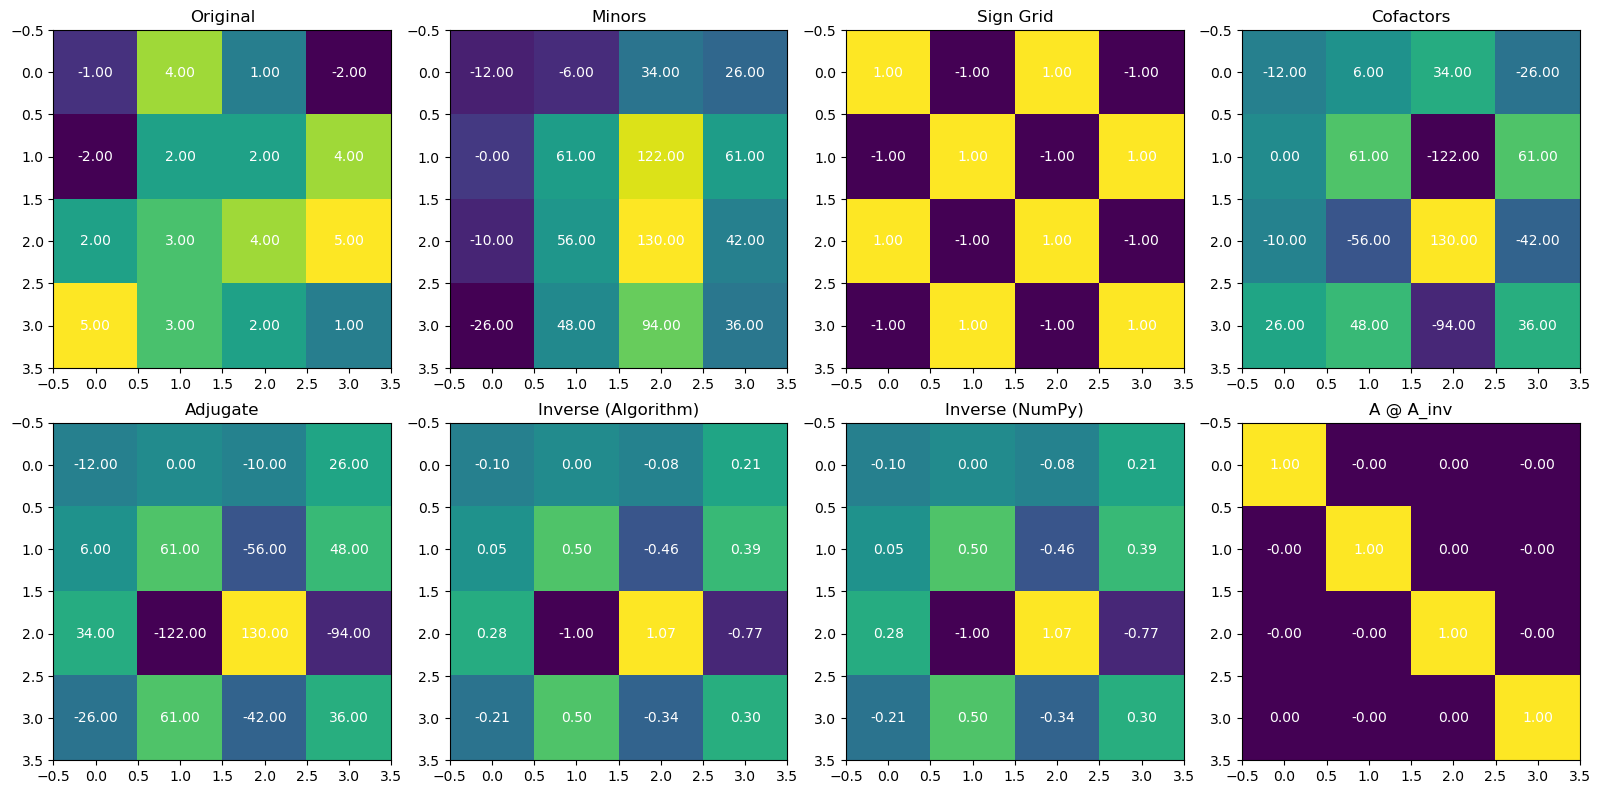

In [35]:
fig, axes = plt.subplots(2,4, figsize=(16,8))

matrices = [
    (original_matrix, "Original"),
    (minors_matrix, "Minors"),
    (sign_grid, "Sign Grid"),
    (cofactor_matrix, "Cofactors"),
    (adjugate_matrix, "Adjugate"),
    (inverse_matrix, "Inverse (Algorithm)"),
    (numpy_inverse, "Inverse (NumPy)"),
    (identity_check, "A @ A_inv")
]

for ax, (matrix, title) in zip(axes.flat, matrices):
    
    image = ax.imshow(matrix)
    ax.set_title(title)

    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, f"{matrix[r,c]:.2f}", ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

### Problem 7 (15 pts)

The LIVE EVIL rule applies to the inverse of multiplied matrices. Test this in code by creating two square full-rank matrices $A$ and $B$, then use Euclidean distance to compare:
1. $(AB)^{-1}$ 
2. $A^{-1}B^{-1}$
3. $B^{-1}A^{-1}$

Before starting to code, make a prediction about which results will be equal. Print out your results using formatting like the following:

```
Distance between (AB)^-1 and (A^-1)(B^-1) is ___
Distance between (AB)^-1 and (B^-1)(A^-1) is ___
Distance between (A^-1)(B^-1) and (B^-1)(A^-1) is ___
```

#### Grading: 
5 points per comparision. 

Prediction:
(AB)^-1 should equal B^-1 A^-1
(AB)^-1 should generally NOT equal A^-1 B^-1
A^-1 B^-1 should generally NOT equal B^-1 A^-1

In [36]:
np.random.seed(21)

# Create two random full-rank square matrices
while True:
    A = np.random.randint(-5, 6, size=(4, 4)).astype(float)
    if np.linalg.matrix_rank(A) == 4:
        break

while True:
    B = np.random.randint(-5, 6, size=(4, 4)).astype(float)
    if np.linalg.matrix_rank(B) == 4:
        break

AB_inv = np.linalg.inv(A @ B)
A_inv_B_inv = np.linalg.inv(A) @ np.linalg.inv(B)
B_inv_A_inv = np.linalg.inv(B) @ np.linalg.inv(A)

dist_1 = np.linalg.norm(AB_inv - A_inv_B_inv)
dist_2 = np.linalg.norm(AB_inv - B_inv_A_inv)
dist_3 = np.linalg.norm(A_inv_B_inv - B_inv_A_inv)

print(f"Distance between (AB)^-1 and (A^-1)(B^-1) is {dist_1}")
print(f"Distance between (AB)^-1 and (B^-1)(A^-1) is {dist_2}")
print(f"Distance between (A^-1)(B^-1) and (B^-1)(A^-1) is {dist_3}")

Distance between (AB)^-1 and (A^-1)(B^-1) is 0.19510334073226063
Distance between (AB)^-1 and (B^-1)(A^-1) is 6.019890384602542e-17
Distance between (A^-1)(B^-1) and (B^-1)(A^-1) is 0.19510334073226057


The distance between (AB)^-1 and (B^-1)(A^-1) should be extremely close to 0.
That confirms the inverse of a product reverses the order.

The other two distances are usually not close to 0 because matrix multiplication is not commutative.